In [1]:


name = "Marie Claire"
age = 23
gpa = 3.8
is_graduate = True

print(name, age, gpa, is_graduate)

Marie Claire 23 3.8 True


In [2]:
model_name = "iris-classifier"
accuracy = 0.87
epoch_count = 12
is_trained = True

print(f"{model_name} reached {accuracy:.2%} accuracy after {epoch_count} epochs and it is trained well")

iris-classifier reached 87.00% accuracy after 12 epochs and it is trained well


In [3]:
raw_value = "0.87"
score = float(raw_value)
rounded = int(score * 100)

def to_float(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return default

print(to_float("1.43"), to_float("N/A"))

1.43 0.0


In [4]:
a = "Marie Claire"      # str
b = 23                  # int
c = 3.8                 # float
d = True                # bool
e = None                # NoneType

print(type(a))
print(type(b))
print(type(c))
print(type(d))
print(type(e))


<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>
<class 'NoneType'>


In [5]:
# Casting: string to float, and float to int
str_value = "9.75"
float_value = float(str_value)
int_value = int(float_value)

print(float_value)   # string becomes a real number
print(int_value)     # converting float to int truncates (cuts off) the decimal, doesn't round

9.75
9


In [6]:
# Conditional: decide model status from accuracy and latency
accuracy = 0.87
latency_ms = 120

if accuracy >= 0.85 and latency_ms <= 150:
    status = "ship it"
elif latency_ms > 150:
    status = "too slow"
else:
    status = "keep training"

print(f"Model status: {status}")

Model status: ship it


In [7]:
# Loop: iterate over scores using enumerate()
scores = [0.62, 0.75, 0.81, 0.87, 0.90]

for epoch, score in enumerate(scores):
    print(f"epoch {epoch}: {score}")
    

epoch 0: 0.62
epoch 1: 0.75
epoch 2: 0.81
epoch 3: 0.87
epoch 4: 0.9


In [8]:
# Four collections — each chosen because it fits the nature of the data

# List: ordered, changeable — good for a sequence of scores that may grow over time
scores_list = [0.62, 0.75, 0.81, 0.87]

# Tuple: ordered, unchangeable — good for fixed data like image dimensions that shouldn't change
image_shape = (224, 224, 3)

# Dict: key-value pairs — good for labeled/structured data like a model's metadata
model_info = {"name": "iris-classifier", "accuracy": 0.87, "epochs": 12}

# Set: unordered, no duplicates — good for tracking unique labels/classes in a dataset
unique_labels = {"setosa", "versicolor", "virginica"}

print(scores_list)
print(image_shape)
print(model_info)
print(unique_labels)

[0.62, 0.75, 0.81, 0.87]
(224, 224, 3)
{'name': 'iris-classifier', 'accuracy': 0.87, 'epochs': 12}
{'virginica', 'setosa', 'versicolor'}


In [9]:
# List comprehension with a filter: keep only scores above 0.75
scores = [0.62, 0.75, 0.81, 0.87, 0.90]
high_scores = [s for s in scores if s > 0.75]
print(high_scores)

# Dict comprehension: pair each score with its epoch number
epoch_scores = {epoch: s for epoch, s in enumerate(scores)}
print(epoch_scores)

[0.81, 0.87, 0.9]
{0: 0.62, 1: 0.75, 2: 0.81, 3: 0.87, 4: 0.9}


In [10]:
def normalise(values, minimum=None, maximum=None):
    """
    Scale a list of numbers into the 0-1 range.

    Args:
        values (list): the numbers to scale
        minimum (float, optional): the value to treat as 0. Defaults to min(values).
        maximum (float, optional): the value to treat as 1. Defaults to max(values).

    Returns:
        list: the scaled values, each between 0 and 1
    """
    if minimum is None:
        minimum = min(values)
    if maximum is None:
        maximum = max(values)

    if maximum == minimum:
        # avoid division by zero when every value is identical
        return [0.0 for _ in values]

    return [(v - minimum) / (maximum - minimum) for v in values]


# Test cases
print(normalise([12, 18, 25, 40]))
print(normalise([5, 5, 5, 5]))  # identical values — should not crash

[0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
[0.0, 0.0, 0.0, 0.0]


In [11]:
def summarise_scores(scores):
    """
    Summarise a list of scores.

    Args:
        scores (list): a list of numeric scores

    Returns:
        dict: count, mean, minimum, maximum, and above_threshold
              (how many scores are >= 0.8). If scores is empty,
              all numeric fields are 0, and minimum/maximum are None
              since there is nothing to compare.
    """
    if len(scores) == 0:
        return {
            "count": 0,
            "mean": 0,
            "minimum": None,
            "maximum": None,
            "above_threshold": 0
        }

    return {
        "count": len(scores),
        "mean": sum(scores) / len(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "above_threshold": len([s for s in scores if s >= 0.8])
    }


# Test on two different inputs
print(summarise_scores([0.62, 0.75, 0.81, 0.87, 0.90]))
print(summarise_scores([]))

{'count': 5, 'mean': 0.79, 'minimum': 0.62, 'maximum': 0.9, 'above_threshold': 3}
{'count': 0, 'mean': 0, 'minimum': None, 'maximum': None, 'above_threshold': 0}


In [12]:
def safe_divide(numerator, denominator, default=0.0):
    """
    Divide two numbers safely.

    Args:
        numerator: the number to divide
        denominator: the number to divide by
        default (float, optional): value returned if the division
            fails (e.g. denominator is zero, or an input isn't numeric).
            Defaults to 0.0.

    Returns:
        float: the result of numerator / denominator, or default if
               the division cannot be performed.
    """
    try:
        return numerator / denominator
    except (ZeroDivisionError, TypeError):
        return default


# Test cases
print(safe_divide(10, 2))          # normal case
print(safe_divide(10, 0))          # divide-by-zero case
print(safe_divide(10, "two"))      # text-input case

5.0
0.0
0.0


In [13]:
import numpy as np

# 1. 1-D array with basic stats
scores_array = np.array([0.62, 0.75, 0.81, 0.87, 0.90, 0.65])
print("Mean:", scores_array.mean())
print("Std:", scores_array.std())
print("Min:", scores_array.min())
print("Max:", scores_array.max())

# 2. 2-D array, shape (3, 4)
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])
print("Shape:", matrix.shape)
print("Transpose shape:", matrix.T.shape)

# 3. Subtract column means (broadcasting)
column_means = matrix.mean(axis=0)
centered = matrix - column_means
print("Column means:", column_means)
print("Centered matrix:\n", centered)

Mean: 0.7666666666666667
Std: 0.10466878978738388
Min: 0.62
Max: 0.9
Shape: (3, 4)
Transpose shape: (4, 3)
Column means: [5. 6. 7. 8.]
Centered matrix:
 [[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


In [14]:
import pandas as pd
import numpy as np

# 1. DataFrame with 4+ columns, 6 rows, one missing value, one text column
data = {
    "student": ["Marie", "Eric", "Aline", "Jean", "Grace", "Paul"],
    "score": [0.87, 0.62, 0.91, np.nan, 0.75, 0.68],
    "attempts": [2, 3, 1, 4, 2, 3],
    "program": ["Electronics", "Software", "Electronics", "Software", "Electronics", "Software"]
}
df = pd.DataFrame(data)

# 2. Inspect the data
print(df.info())
print(df.describe())
print(df.isna().sum())

# 3. Filter and sort
passed = df[df["score"] >= 0.7].sort_values("score", ascending=False)
print(passed)

# 4. Add a derived column
df["pass_fail"] = df["score"] >= 0.7
print(df)

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   student   6 non-null      str    
 1   score     5 non-null      float64
 2   attempts  6 non-null      int64  
 3   program   6 non-null      str    
dtypes: float64(1), int64(1), str(2)
memory usage: 324.0 bytes
None
          score  attempts
count  5.000000  6.000000
mean   0.766000  2.500000
std    0.123004  1.048809
min    0.620000  1.000000
25%    0.680000  2.000000
50%    0.750000  2.500000
75%    0.870000  3.000000
max    0.910000  4.000000
student     0
score       1
attempts    0
program     0
dtype: int64
  student  score  attempts      program
2   Aline   0.91         1  Electronics
0   Marie   0.87         2  Electronics
4   Grace   0.75         2  Electronics
  student  score  attempts      program  pass_fail
0   Marie   0.87         2  Electronics       True
1    Eric   0.62         3     Software     

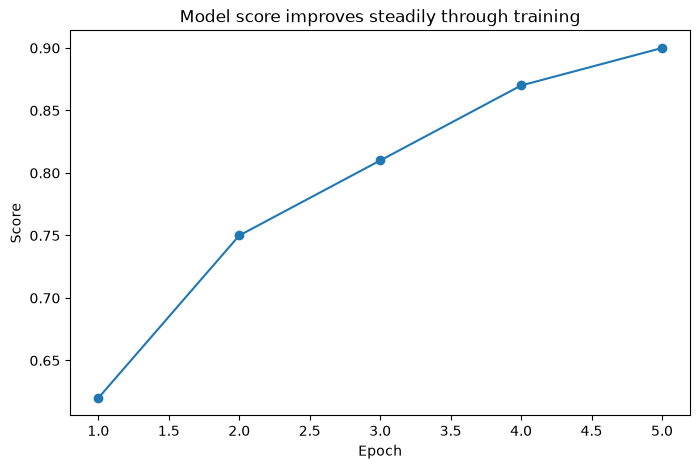

In [15]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4, 5]
scores = [0.62, 0.75, 0.81, 0.87, 0.90]

plt.figure(figsize=(8, 5))
plt.plot(epochs, scores, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Model score improves steadily through training")
plt.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")
plt.show()